# 03 · Filtering, sampling and spectral inspection

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Design and inspect EEG filters, distinguish offline and causal processing, and measure attenuation on real EEG.

**Data:** MNE EEGBCI subject 1, run 4

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### Motor imagery and sensorimotor rhythms

Motor imagery is the internal rehearsal of movement without overt execution. In a sensorimotor-rhythm BCI, the intended action is inferred from changes in oscillatory activity, commonly within the mu and beta ranges. Event-related desynchronization denotes reduced band power relative to a reference interval; it does not mean that the EEG voltage becomes uniformly negative. The spatial and temporal distributions are variable across participants and trials.

A minimal cue-based experiment presents a fixation interval followed by a left- or right-hand instruction, an imagery interval and a rest interval. The participant imagines the kinesthetic sensation of movement while maintaining posture. An EEG cap, amplifier and acquisition computer record continuous signals; a stimulus computer records cue onset and class. Additional EOG or EMG channels, when actually acquired, can support artifact assessment. Their presence must not be assumed from scalp EEG alone.

A trial is one instructed imagery interval; a run is a sequence of trials; a session is a recording visit. These levels are not exchangeable independent samples. Run-wise evaluation assesses transfer across recording blocks, whereas subject-wise evaluation addresses a different generalization claim. Averaging signed voltages can suppress induced rhythms whose phases vary between trials; band power or time–frequency estimates are therefore central measurements.

### Acquisition provenance and instructional protocol

PhysioNet EEGBCI: 64 scalp channels, 160 Hz. Runs 4, 8 and 12 encode imagined left/right fist movement; individual lessons may use only run 4. Acquisition used BCI2000. The original database also contains executed movements and other imagery tasks.

**Acquisition reference:** [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Cue and task instruction → continuous EEG → imagery epoch → spectral/spatial features. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

A discrete linear time-invariant filter has $y[n]=\sum_k h[k]x[n-k]$ and frequency response $H(f)=\sum_k h[k]e^{-j2\pi fk/f_s}$. For a symmetric causal FIR of length $L$, group delay is $(L-1)/(2f_s)$ seconds. Forward–backward filtering has effective magnitude $|H(f)|^2$ and is noncausal. Nyquist frequency is $f_s/2$; anti-alias filtering is required before reducing sampling frequency.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


**Methodological reading:** [Widmann, Schröger and Maess (2015). Digital filter design for electrophysiological data—a practical approach](https://doi.org/10.1016/j.jneumeth.2014.08.002). Filter response, distortion and design considerations.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Relate convolution, impulse response and frequency response.
- Measure passband behavior, transition width and causal delay.
- Demonstrate aliasing and explain anti-alias filtering before resampling.
- Choose different passbands for ERP and sensorimotor-power tasks.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

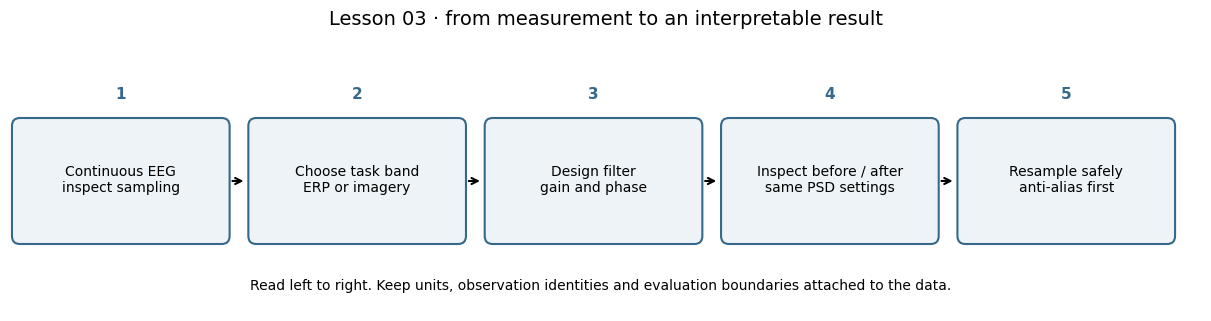

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Continuous EEG\ninspect sampling', 'Choose task band\nERP or imagery', 'Design filter\ngain and phase', 'Inspect before / after\nsame PSD settings', 'Resample safely\nanti-alias first']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 03 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Continuous EEG: inspect sampling → Choose task band: ERP or imagery → Design filter: gain and phase → Inspect before / after: same PSD settings → Resample safely: anti-alias first.

## Symbols and a calculation by hand

$h[k]$: FIR coefficients; $L$: tap count; $f_s$: sampling rate; $H(f)$: complex frequency response.

### Derive the operation before calling the library

Convolution shifts and weights samples: $y[n]=\sum_{k=0}^{L-1}h[k]x[n-k]$. For $h=[1/3,1/3,1/3]$ and an impulse of amplitude 3, three consecutive outputs equal 1. The output is spread in time even though the total coefficient sum is one.

A symmetric causal FIR of odd length $L$ has group delay $(L-1)/2$ samples. For 129 taps at 160 Hz, delay is $64/160=0.4$ s. Frequency-response amplitude is plotted with $20\log_{10}|H|$; a power ratio uses $10\log_{10}(P_2/P_1)$. The factor differs because power is proportional to squared amplitude.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Filtering is a transformation with consequences

A filter is not a general “clean EEG” button. It changes amplitude and sometimes phase as a function of frequency. For a sinusoidal input at frequency $f$, a linear time-invariant filter scales its amplitude by $|H(f)|$ and shifts phase by $\arg H(f)$. When a transient contains many frequencies, those changes alter its shape. This is why ERP latency and morphology require careful filter choices.

For a finite impulse response filter, each output is a weighted sum of recent inputs. A moving average has equal weights and suppresses fast changes, but its frequency response has sidelobes rather than an ideal brick wall. Designed FIR filters choose weights to control these tradeoffs. Sharper transitions generally require longer filters. A long filter can extend farther in time than a short teaching epoch.

An IIR filter uses feedback from previous outputs and can achieve a sharp magnitude response with fewer coefficients. Numerical implementation matters: second-order sections are preferable to a single high-order polynomial for many practical designs. Forward–backward filtering applies a filter in both temporal directions; it cancels phase in the interior but requires future data and still has boundary behavior. Zero phase does not mean zero consequences.

### Sampling changes what frequencies mean

The sampled sinusoid $\sin(2\pi fn/f_s)$ is indistinguishable from certain sinusoids differing by integer multiples of $f_s$. Frequencies above Nyquist can fold into lower frequencies. Once aliasing has occurred at acquisition, a digital low-pass cannot reconstruct the lost distinction. Before downsampling existing data, attenuate frequencies above the new Nyquist limit; simply retaining every second sample is not a complete resampling method.

### A reproducible filter report

Record filter family, passband, transition bands, phase mode, sampling rate, treatment of boundaries and whether filtering preceded epoching. For separate runs, maintain discontinuity annotations or process each run independently. For a temporal train/test split within one run, account for filter support around the boundary. A pipeline can leak samples even when the filter never uses class labels.

## Visual intuition · Watch convolution build an output

**Independent exercise:** At output index 3, which three input samples are included? Calculate their weighted sum before reading the bars.

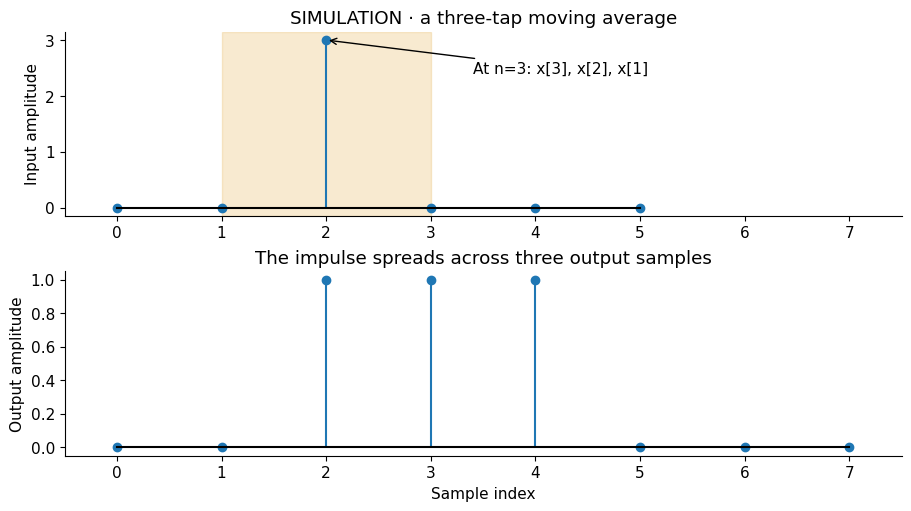

In [3]:
vis_x=np.array([0.,0.,3.,0.,0.,0.]);vis_h=np.ones(3)/3
vis_y=np.convolve(vis_x,vis_h)
fig,axes=plt.subplots(2,1,figsize=(9,5),constrained_layout=True)
axes[0].stem(np.arange(len(vis_x)),vis_x,basefmt='k-')
axes[0].axvspan(1,3,color='#e8bb65',alpha=.3)
axes[0].set(xlim=(-.5,7.5),ylabel='Input amplitude',title='SIMULATION · a three-tap moving average')
axes[0].annotate('At n=3: x[3], x[2], x[1]',xy=(2,3),xytext=(3.4,2.4),arrowprops=dict(arrowstyle='->'))
axes[1].stem(np.arange(len(vis_y)),vis_y,basefmt='k-')
axes[1].set(xlim=(-.5,7.5),xlabel='Sample index',ylabel='Output amplitude',title='The impulse spreads across three output samples')
plt.show()

### Worked interpretation

At n=3 the sum is (0+3+0)/3=1. The same impulse contributes at n=2, 3 and 4. A filter changes temporal shape as well as frequency content; the drawing is a numerical convolution example, not an ERP.

## Guided practice 1 · convolution by hand

A three-sample moving average uses weights [1/3, 1/3, 1/3]. For the sequence [0, 0, 3, 0, 0], predict the full convolution. The response to a single impulse reveals the filter itself.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_input=np.array([0.,0.,3.,0.,0.])
demo_kernel=np.ones(3)/3
demo_output=np.convolve(demo_input,demo_kernel,mode='full')
print('Input:',demo_input,'\nOutput:',demo_output)
assert np.allclose(demo_output,[0,0,1,1,1,0,0])

Input: [0. 0. 3. 0. 0.] 
Output: [0. 0. 1. 1. 1. 0. 0.]


### Why this result makes sense

The energy of the sharp event spreads across neighboring samples. Smoothing is a change in temporal resolution, not just removal of noise.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · expose aliasing

At a sample rate of 100 Hz, a cosine at 70 Hz and one at 30 Hz produce the same samples. Compute the two sequences and compare. Cosine avoids the sign reversal that appears in the analogous sine example.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_fs=100
demo_t=np.arange(100)/demo_fs
high=np.cos(2*np.pi*70*demo_t)
aliased=np.cos(2*np.pi*30*demo_t)
print('Maximum difference:',np.max(np.abs(high-aliased)))
assert np.allclose(high,aliased,atol=1e-12)

Maximum difference: 1.0341727474383333e-13


### Why this result makes sense

No downstream classifier can determine which original analog cosine generated these samples without additional information. Acquisition anti-alias filtering is essential.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · FIR length versus delay

Hold the passband fixed and change the number of taps. Use the same axes. Calculate the delay for a symmetric causal FIR and compare the transition shapes.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

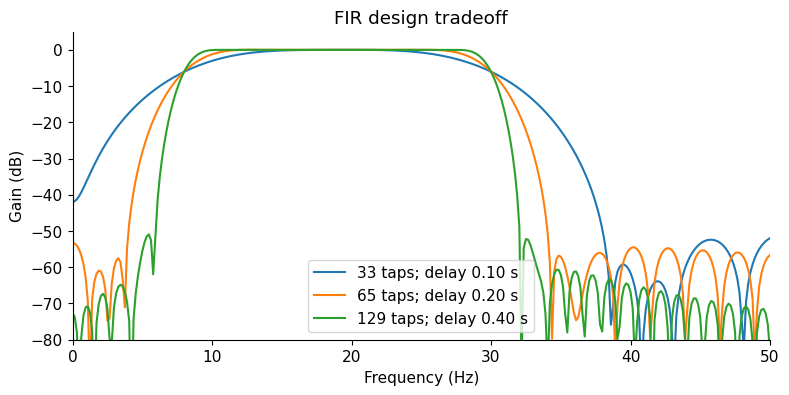

In [6]:
fig,ax=plt.subplots()
for taps in [33,65,129]:
    h=signal.firwin(taps,[8,30],fs=160,pass_zero=False)
    f_demo,H_demo=signal.freqz(h,fs=160)
    ax.plot(f_demo,20*np.log10(np.maximum(abs(H_demo),1e-8)),
            label=f'{taps} taps; delay {(taps-1)/(2*160):.2f} s')
ax.set(xlim=(0,50),ylim=(-80,5),xlabel='Frequency (Hz)',ylabel='Gain (dB)',title='FIR design tradeoff')
ax.legend();plt.show()

### Why this result makes sense

A longer filter improves frequency selectivity while spreading information over a longer interval. Decide whether the task can tolerate that support.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · downsampling with and without anti-alias protection

Mix 10 Hz and 70 Hz activity at 200 Hz, then reduce to 100 Hz. Compare direct slicing with a resampling method that includes anti-alias filtering.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

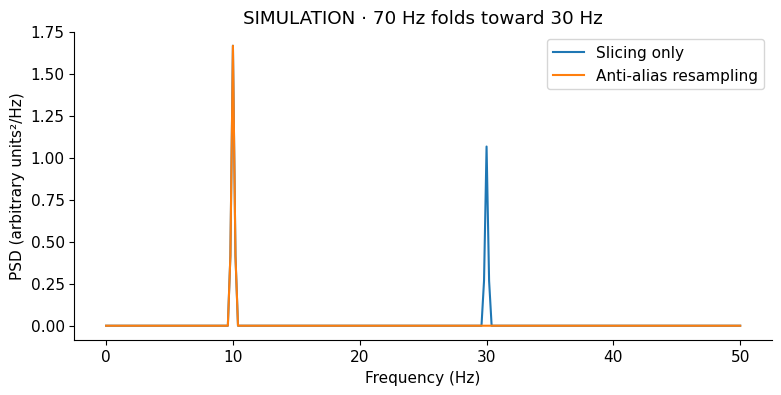

In [7]:
demo_fs=200;demo_t=np.arange(2000)/demo_fs
mixed=np.sin(2*np.pi*10*demo_t)+.8*np.sin(2*np.pi*70*demo_t)
unsafe=mixed[::2]
safer=signal.resample_poly(mixed,1,2)
fig,ax=plt.subplots()
for values,name in [(unsafe,'Slicing only'),(safer,'Anti-alias resampling')]:
    f_demo,p_demo=signal.welch(values,fs=100,nperseg=500)
    ax.plot(f_demo,p_demo,label=name)
ax.set(xlabel='Frequency (Hz)',ylabel='PSD (arbitrary units²/Hz)',title='SIMULATION · 70 Hz folds toward 30 Hz')
ax.legend();plt.show()

### Why this result makes sense

The extra lower-frequency peak after naive slicing is an artifact of resampling, not a new physiological rhythm.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Delay calculation

Implement `fir_delay`. Check that doubling the sampling rate halves delay in seconds for the same tap count.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def fir_delay(n_taps, sampling_rate):
    # TODO: delay in seconds for a symmetric causal FIR.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def fir_delay(n_taps,sampling_rate):
    return (n_taps-1)/(2*sampling_rate)

In [10]:
answer=fir_delay(129,160)
if answer is not None:
    assert np.isclose(answer,.4); print('Delay check passed.')
else:
    print('Exercise pending: implement fir_delay.')

Delay check passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A finite impulse response filter computes $y[n]=\sum_{k=0}^{L-1}h[k]x[n-k]$. Its frequency response is $H(f)=\sum_k h[k]e^{-j2\pi fk/f_s}$. The transition band, not just cutoff, controls required length. A symmetric FIR has group delay $(L-1)/(2f_s)$ when used causally.

Forward–backward IIR filtering cancels phase offline but uses future samples and squares the magnitude response. It cannot be copied into a live BCI. Filtering short epochs separately creates edge artifacts; filter each continuous run before epoching and preserve run boundaries. Do not filter across a train/test temporal boundary without a guard region at least covering the effective filter support.

Welch PSD averages windowed periodograms: $\hat P(f)=K^{-1}\sum_k|\mathcal F\{w x_k\}|^2/(f_s\sum_n w[n]^2)$. Units are $V^2/Hz$. Frequency resolution is approximately $f_s/N_{FFT}$ but zero padding does not create new information. Downsampling needs anti-alias filtering. Notch only a measured line component; a 50/60 Hz notch is redundant after a sufficiently strong 30 Hz low-pass.

## Load and inspect a real run
Choose the filter for the intended paradigm. The 8–30 Hz band here is for motor imagery, not P300.

Read one continuous imagery run and standardize channel names so C3 refers to the expected sensor. Keep the original Raw object as the baseline for comparison; filtering a copy makes before/after inspection reproducible.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Fetch only the specified participant/run files; the cache prevents repeat downloads.

**3.** Read continuous voltage samples and metadata into an MNE Raw object.

**4.** Standardize dataset channel names so later sensor-name selection is meaningful.

**5.** Attach sensor coordinates; this does not perform anatomical source localization.

**6.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Fetch only the specified participant/run files; the cache prevents repeat downloads.
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
# Read continuous voltage samples and metadata into an MNE Raw object.
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
# Standardize dataset channel names so later sensor-name selection is meaningful.
eegbci.standardize(raw)
# Attach sensor coordinates; this does not perform anatomical source localization.
raw.set_montage('standard_1005')
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(raw)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Channel types:', set(raw.get_channel_types()))

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


/tmp/ipykernel_476445/1909471534.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


### Inspect and interpret

Verify the sampling rate and duration. Identify the Nyquist frequency and check that every requested filter cutoff lies below it.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Calculate the Nyquist limit and sample interval

**Independent exercise:** Read the real sampling rate. Compute the highest representable frequency and milliseconds per sample.

**My reasoning / hand calculation:** _write here._

In [12]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Nyquist = fs/2; one sample interval = 1/fs.

### Worked solution

Run the following calculation after attempting your own version.

In [13]:
lab_fs=raw.info['sfreq']
print('Sampling rate:',lab_fs,'Hz')
print('Nyquist:',lab_fs/2,'Hz')
print('Sample interval:',1000/lab_fs,'ms')

Sampling rate: 160.0 Hz
Nyquist: 80.0 Hz
Sample interval: 6.25 ms


### Interpret and check

Every digital cutoff must be compatible with the sampling rate, including its transition band. A requested 100 Hz notch cannot be represented by a recording whose Nyquist frequency is only 80 Hz.

## Compare spectra
Use the same PSD parameters before and after filtering. Decibels below are referenced to one V²/Hz.

Use identical Welch settings and the same sensor for both PSD curves. A band-pass filter should attenuate out-of-band energy without creating a new physiological interpretation for the remaining peaks. The logarithmic display uses a consistent reference.

### Step 2.1 · trace the next operation

**1.** Apply the declared frequency filter; copy first when the original must be preserved.

**2.** Store this intermediate result so the next operation can be traced and inspected.

In [14]:
# Apply the declared frequency filter; copy first when the original must be preserved.
filtered = raw.copy().filter(8, 30)
# Store this intermediate result so the next operation can be traced and inspected.
channel = raw.ch_names.index('C3')

### Step 2.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

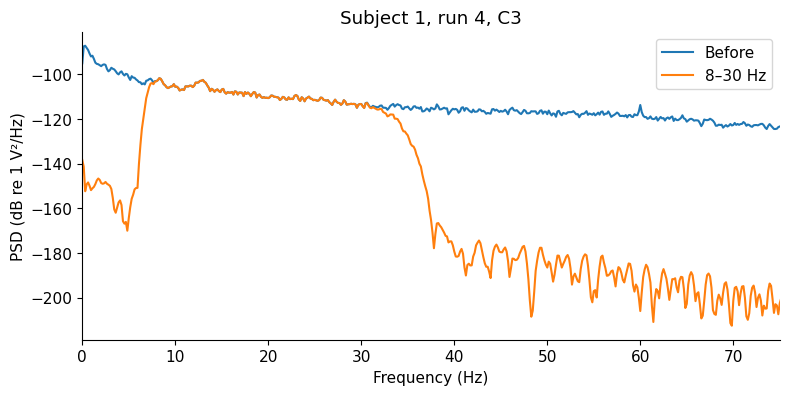

In [15]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Plot each named condition on comparable axes without changing its observations.
for obj, name in [(raw, 'Before'), (filtered, '8–30 Hz')]:
    f, p = signal.welch(obj.get_data()[channel], fs=obj.info['sfreq'], nperseg=1024)
    ax.plot(f, 10 * np.log10(np.maximum(p, 1e-30)), label=name)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlim=(0, 75), xlabel='Frequency (Hz)', ylabel='PSD (dB re 1 V²/Hz)', title='Subject 1, run 4, C3')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Locate the passband, transition regions and attenuated frequencies. Explain why the output PSD is not the filter response itself: it combines the input spectrum with the filter action.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Decide whether to add a notch

**Independent exercise:** Does every EEG pipeline need a 50 or 60 Hz notch? Use the displayed spectra and chosen passband to explain.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

An operation needs a signal-processing purpose, not just a place in a checklist.

### Worked solution

No. Inspect whether line-frequency interference is present and whether the existing low-pass already attenuates it sufficiently. A notch can be useful when the analysis retains frequencies near mains, but it can also remove wanted information. Report evidence and inspect before/after spectra.

## Inspect FIR and causal delay
An impulse exposes timing that a smooth waveform can hide.

An impulse response and a frequency response describe the same linear filter in different domains. The symmetric FIR has a calculable causal delay; the offline zero-phase operation used by MNE handles phase differently. Resampling changes the time grid and requires anti-alias protection.

### Step 3.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Design finite impulse-response coefficients from the requested band and sample rate.

**3.** Evaluate the filter’s complex frequency response, not the data spectrum.

In [16]:
# Store this intermediate result so the next operation can be traced and inspected.
fs = raw.info['sfreq']
# Design finite impulse-response coefficients from the requested band and sample rate.
h = signal.firwin(129, [8, 30], pass_zero=False, fs=fs)
# Evaluate the filter’s complex frequency response, not the data spectrum.
f, H = signal.freqz(h, fs=fs)

### Step 3.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Use a log transform on positive power; a small floor avoids taking log of zero.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**6.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**7.** Render the completed figure and inspect labels, units and the comparison.

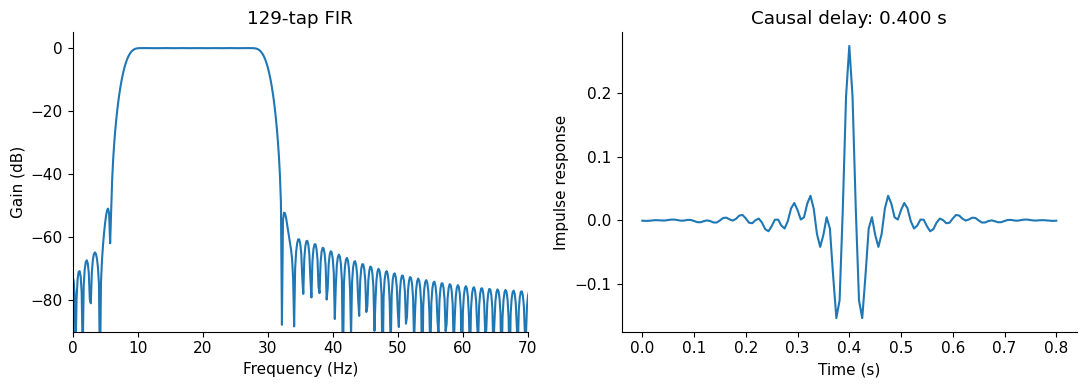

In [17]:
# Create axes; plotting changes the display, not the analyzed data.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Use a log transform on positive power; a small floor avoids taking log of zero.
axes[0].plot(f, 20 * np.log10(np.maximum(abs(H), 1e-08)))
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
axes[0].set(xlim=(0, 70), ylim=(-90, 5), xlabel='Frequency (Hz)', ylabel='Gain (dB)', title='129-tap FIR')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
axes[1].plot(np.arange(len(h)) / fs, h)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
axes[1].set(xlabel='Time (s)', ylabel='Impulse response', title=f'Causal delay: {(len(h) - 1) / (2 * fs):.3f} s')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
plt.tight_layout()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Step 3.3 · trace the next operation

**1.** Change the sampling grid with anti-alias protection and updated metadata.

**2.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

In [18]:
# Change the sampling grid with anti-alias protection and updated metadata.
resampled = filtered.copy().resample(100)
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert resampled.info['sfreq'] == 100

### Inspect and interpret

Compare the printed delay with the impulse-response center. State which operation could run on an incoming stream and which requires future samples. Verify the new sampling rate after resampling.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Measure the filter’s causal delay

**Independent exercise:** Locate the symmetry center of the 129-tap FIR and convert it to seconds. Repeat the calculation for 65 taps without changing the sample rate.

**My reasoning / hand calculation:** _write here._

In [19]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

A symmetric odd-length FIR centers at (L−1)/2.

### Worked solution

Run the following calculation after attempting your own version.

In [20]:
lab_lengths=np.array([65,129])
lab_delays=(lab_lengths-1)/(2*fs)
print(pd.DataFrame({'taps':lab_lengths,'delay_samples':(lab_lengths-1)/2,'delay_seconds':lab_delays}))
assert np.allclose(h,h[::-1])

   taps  delay_samples  delay_seconds
0    65           32.0            0.2
1   129           64.0            0.4


### Interpret and check

The 129-tap filter has twice the delay of the 65-tap filter at the same rate. This delay describes causal application of that symmetric FIR, not the final timing of MNE’s offline zero-phase filtering operation.

## Practice 5 · Explain why slicing is not resampling

**Independent exercise:** A student writes raw_data[:, ::2]. What extra operation is needed before treating that as downsampled EEG?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Signals above the new Nyquist limit fold into lower frequencies.

### Worked solution

Apply appropriate anti-alias filtering before decimation, or use a resampling function that performs it. Also update sampling metadata and event timing consistently. Direct slicing of a 70 Hz component from 200 to 100 Hz creates an apparent 30 Hz component.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

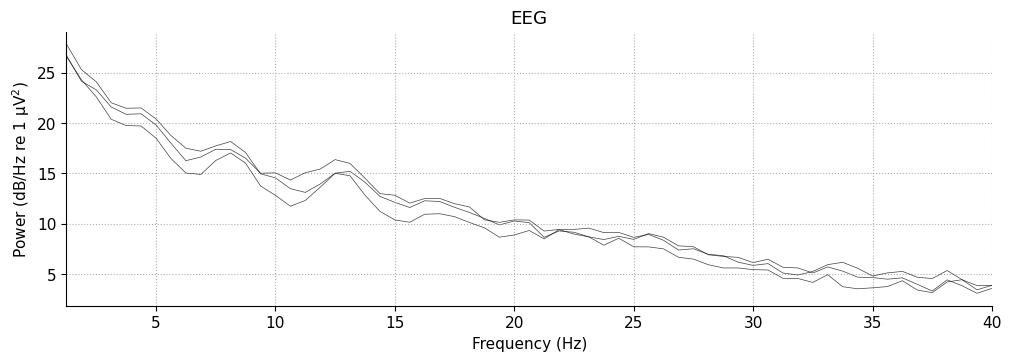

In [21]:
# Estimate the spectrum from the recorded EEG, retaining MNE metadata.
recorded_spectrum = raw.compute_psd(method='welch', fmin=1, fmax=40, picks=['C3', 'Cz', 'C4'], n_fft=256, verbose=False)
recorded_spectrum.plot(average=False, spatial_colors=False, show=False)
plt.show()

### Figure interpretation and independent exercise

The horizontal axis represents frequency; the vertical axis represents spectral density on the scale indicated by MNE. Compare central channels and identify broad-band versus narrow-band structure. A spectral difference alone does not establish task discrimination. This panel uses recorded EEG; controlled examples elsewhere remain explicitly synthetic.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

A filter’s band, transition width, length, phase and boundary behavior all matter. Causal delay, zero-phase future-sample use and aliasing are separate issues. Safe resampling combines signal processing with consistent timing metadata.

## If your result is different

If a cutoff is rejected, compare it and its transition band with Nyquist. If an edge rings, inspect impulse support, padding and interval length before shortening the filter blindly.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE filtering background](https://mne.tools/stable/auto_tutorials/preprocessing/25_background_filtering.html) · [SciPy signal](https://docs.scipy.org/doc/scipy/reference/signal.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.


### Primary methodological literature

- [Widmann, Schröger and Maess (2015). Digital filter design for electrophysiological data—a practical approach](https://doi.org/10.1016/j.jneumeth.2014.08.002). Filter response, distortion and design considerations.